<a href="https://colab.research.google.com/github/Sid-istic/GNSS_Predictions/blob/main/LSTM_Training_GNSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
FEATURE_COLS = ["x_error(m)", "y_error(m)", "z_error(m)", "satclockerror(m)"]
TARGET_COL = "satclockerror(m)"

In [ ]:
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

In [ ]:
LOOKBACK = 16
HORIZON = 4

def create_sequences(df, features, target, lookback=16, horizon=4):

    X, y = [], []

    X_vals = df[features].values
    y_vals = df[target].values

    for i in range(len(df) - lookback - horizon + 1):

        X.append(X_vals[i:i+lookback])
        y.append(y_vals[i+lookback:i+lookback+horizon])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (315, 16, 4)
Test shape: (22, 16, 4)


In [ ]:
model = Sequential([

    LSTM(64, return_sequences=False, input_shape=(LOOKBACK, len(FEATURE_COLS))),

    Dense(32, activation="relu"),

    Dense(HORIZON)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,876 (77.64 KB)

 Trainable params: 19,876 (77.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,
    batch_size=32,

    validation_split=0.1,

    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0635 - mae: 0.2218 - val_loss: 0.0046 - val_mae: 0.0556
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0121 - mae: 0.0790 - val_loss: 0.0068 - val_mae: 0.0718
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0093 - mae: 0.0551 - val_loss: 9.9461e-04 - val_mae: 0.0228
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0085 - mae: 0.0470 - val_loss: 7.2221e-04 - val_mae: 0.0239
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079 - mae: 0.0454 - val_loss: 8.5518e-04 - val_mae: 0.0273
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0075 - mae: 0.0397 - val_loss: 2.6654e-04 - val_mae: 0.0117
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0076 - mae: 0.0384 - val_loss: 4.5963e-04 - val_mae: 0.0188
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0075 - mae: 0.0394 - val_loss: 5.4055e-04 - val_mae: 0.0219
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss:

In [ ]:
preds = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


In [ ]:
y_true = y_test.flatten()
y_pred = preds.flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.0156919768326485
RMSE: 0.022991859815602148


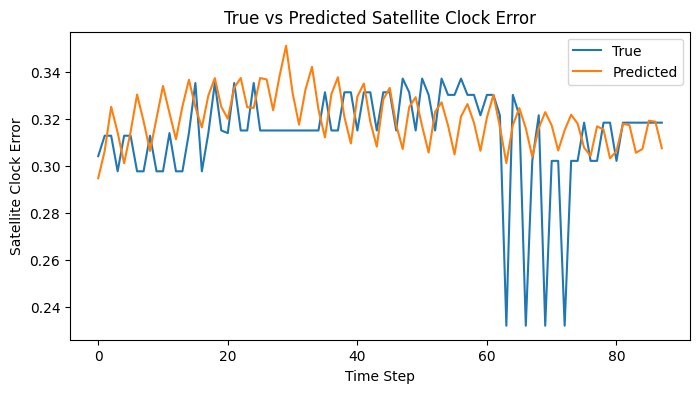

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(y_true[:100], label="True")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Satellite Clock Error")
plt.title("True vs Predicted Satellite Clock Error")

plt.show()

In [ ]:
results = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

results.to_csv("lstm_predictions.csv", index=False)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

HORIZONS_TO_REPORT = 3   # H1, H2, H3

results = []

for h in range(HORIZONS_TO_REPORT):

    y_true_h = y_test[:, h]
    y_pred_h = preds[:, h]

    mae = mean_absolute_error(y_true_h, y_pred_h)
    rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

    results.append((mae, rmse))

    print(f"Horizon {h+1}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print()

Horizon 1
MAE : 0.014052720233372873
RMSE: 0.02127543100028323

Horizon 2
MAE : 0.015787061466310783
RMSE: 0.02503875231826473

Horizon 3
MAE : 0.01679557619291477
RMSE: 0.02422452007496925

